# Diccionario de datos
- transaction_id : Unique sequential ID representing an individual transaction
- transaction_date : Date of the transaction (MM/DD/YY)
- transaction_time : Timestamp of the transaction (HH:MM:SS)
- transaction_qty : Quantity of items sold
- store_id : Unique ID of the coffee shop where the transaction took place
- store_location : Location of the coffee shop where the transaction took place
- product_id : Unique ID of the product sold
- unit_price : Retail price of the product sold
- product_category : Description of the product category
- product_type : Description of the product type
- product_detail : Description of the product detail

# Carga y exploración de datos

In [3]:
# Librerias necesarias para el analisis de datos
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

C:\Users\alexe\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# https://www.kaggle.com/datasets/ahmedabbas757/coffee-sales/data
path = kagglehub.dataset_download("ahmedabbas757/coffee-sales")
print("Path to dataset files:", path)

df = pd.read_excel(path + "/Coffee Shop Sales.xlsx")
df.head()

Path to dataset files: C:\Users\alexe\.cache\kagglehub\datasets\ahmedabbas757\coffee-sales\versions\1


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [5]:
df.describe()

,transaction_id,transaction_date,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2023-04-15 11:50:32.173609984,1.438276,5.342063,47.918607,3.382219
min,1.000000,2023-01-01 00:00:00,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2023-03-06 00:00:00,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2023-04-24 00:00:00,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2023-05-30 00:00:00,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2023-06-30 00:00:00,8.000000,8.000000,87.000000,45.000000
std,43153.600016,NaN,0.542509,2.074241,17.930020,2.658723


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [7]:
# Verificar si hay valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64


In [8]:
# Variablles categoricas
categorical_cols = df.select_dtypes(include=["object"]).columns
print("Columnas categóricas:", categorical_cols)
# Variables numéricas
numeric_cols = df.select_dtypes(include=["number"]).columns
print("Columnas numéricas:", numeric_cols)

Columnas categóricas: Index(['transaction_time', 'store_location', 'product_category',
       'product_type', 'product_detail'],
      dtype='object')
Columnas numéricas: Index(['transaction_id', 'transaction_qty', 'store_id', 'product_id',
       'unit_price'],
      dtype='object')


In [9]:
# Tiendas únicas
print("Número de tiendas:", len(df["store_id"].unique()))
print(df["store_id"].unique())
print("---------------------------------")
# Categorias de productos únicas
print("Categorías de productos:", len(df["product_category"].unique()))
print(df["product_category"].unique())
# Productos únicos
print("---------------------------------")
print("Productos únicos:", len(df["product_type"].unique()))
print(df["product_type"].unique())

Número de tiendas: 3
[5 8 3]
---------------------------------
Categorías de productos: 9
['Coffee' 'Tea' 'Drinking Chocolate' 'Bakery' 'Flavours' 'Loose Tea'
 'Coffee beans' 'Packaged Chocolate' 'Branded']
---------------------------------
Productos únicos: 29
['Gourmet brewed coffee' 'Brewed Chai tea' 'Hot chocolate' 'Drip coffee'
 'Scone' 'Barista Espresso' 'Brewed Black tea' 'Brewed Green tea'
 'Brewed herbal tea' 'Biscotti' 'Pastry' 'Organic brewed coffee'
 'Premium brewed coffee' 'Regular syrup' 'Herbal tea' 'Gourmet Beans'
 'Organic Beans' 'Sugar free syrup' 'Drinking Chocolate' 'Premium Beans'
 'Chai tea' 'Green beans' 'Espresso Beans' 'Green tea' 'Organic Chocolate'
 'Housewares' 'Black tea' 'House blend Beans' 'Clothing']


De abajo solo importa transaction_qty y poco unit_price

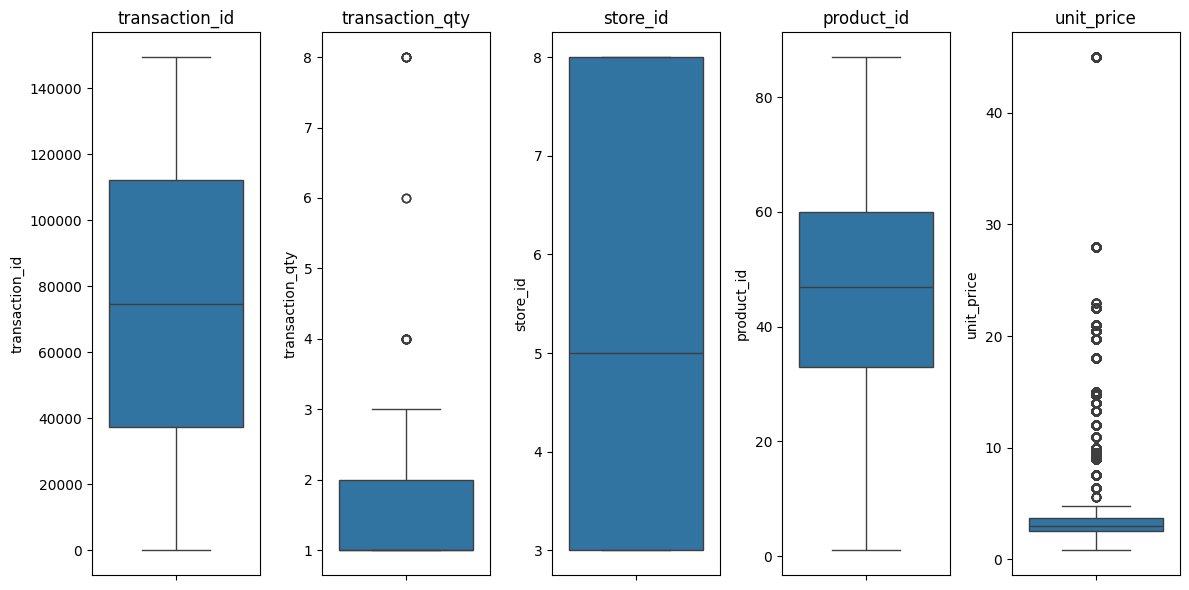

In [10]:
# Mostrar boxplot para detectar outliers en todas las columnas numéricas
plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols):
    plt.subplot(1, len(numeric_cols), i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'{col}')
plt.tight_layout()
plt.show()

In [11]:
# Crear columna de semana (año-semana)
df['total'] = df['transaction_qty'] * df['unit_price']
df['semana'] = df['transaction_date'].dt.to_period('W')
ventas_semana_tienda = df.groupby(['store_id', 'semana'])['total'].sum().reset_index()
ventas_semana = df.groupby(['semana'])['total'].sum().reset_index()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


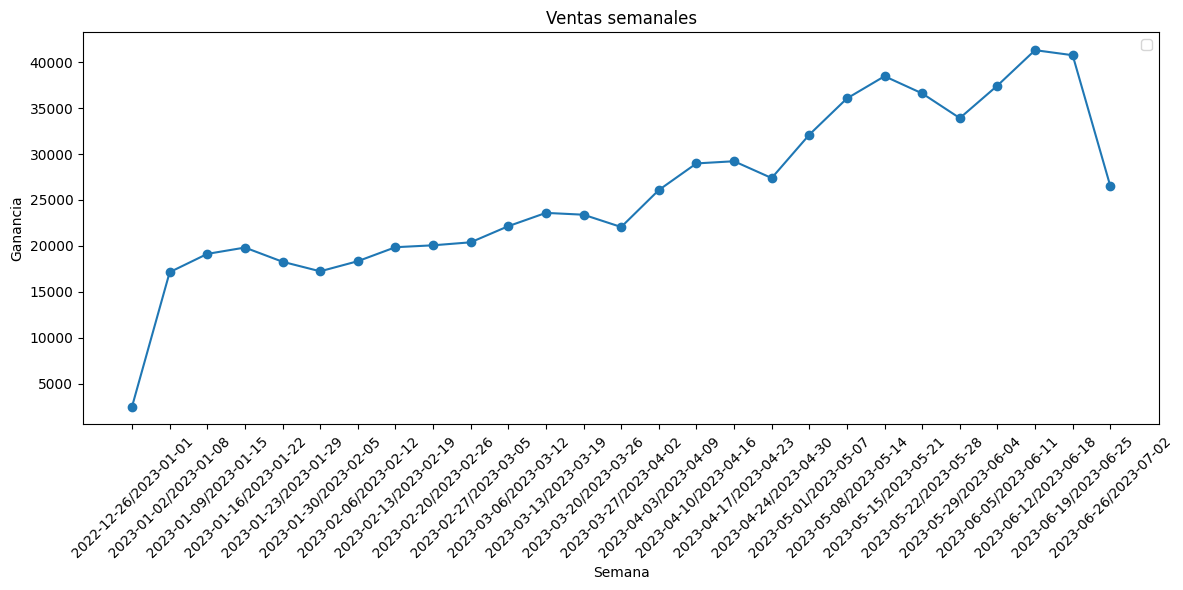

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

plt.plot(ventas_semana['semana'].astype(str), ventas_semana['total'], marker='o')

plt.xticks(rotation=45)
plt.xlabel("Semana")
plt.ylabel("Ganancia")
plt.title("Ventas semanales")
plt.legend()

plt.tight_layout()
plt.show()

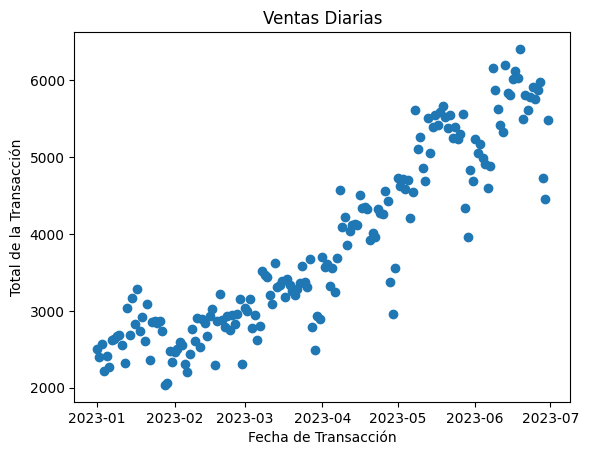

In [19]:
ventas_dia = df.groupby('transaction_date')['total'].sum().reset_index()

plt.scatter(ventas_dia['transaction_date'], ventas_dia['total'])
plt.xlabel('Fecha de Transacción')
plt.ylabel('Total de la Transacción')
plt.title('Ventas Diarias')
plt.show()

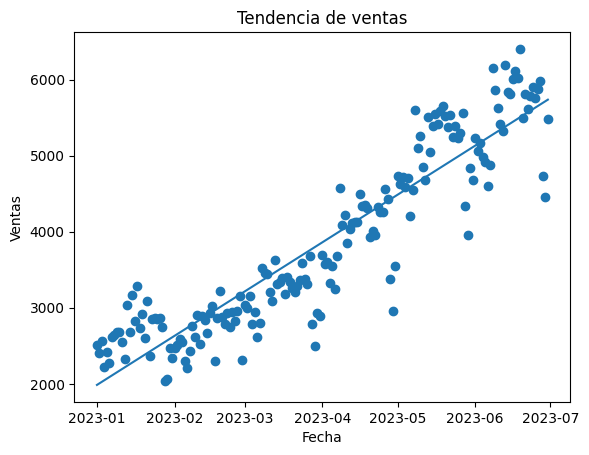

In [84]:
import numpy as np
df_daily = df.groupby('transaction_date')['total'].sum().reset_index()
# Convertir fechas a número
x = df_daily['transaction_date'].map(pd.Timestamp.toordinal)
y = df_daily['total']

# Regresión lineal
m, b = np.polyfit(x, y, 1)

# Línea de tendencia
y_pred = m * x + b

plt.scatter(df_daily['transaction_date'], y)
plt.plot(df_daily['transaction_date'], y_pred)

plt.title("Tendencia de ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")

plt.show()

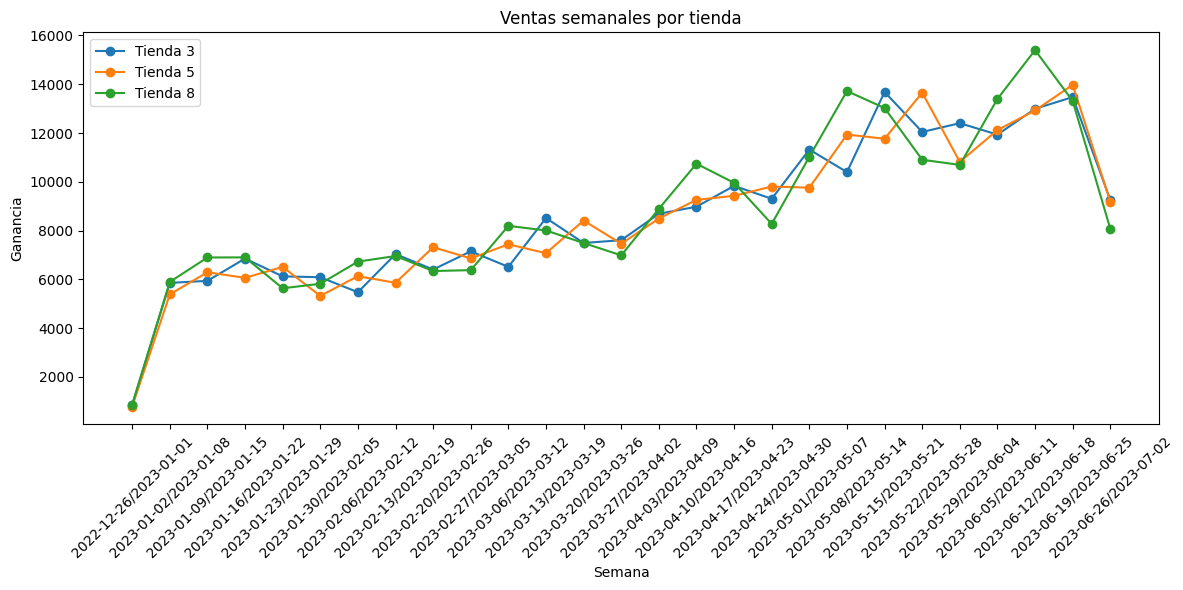

In [14]:
plt.figure(figsize=(12, 6))

for tienda in ventas_semana_tienda['store_id'].unique():
    data_tienda = ventas_semana_tienda[ventas_semana_tienda['store_id'] == tienda]
    
    plt.plot(data_tienda['semana'].astype(str), 
             data_tienda['total'], 
             marker='o', 
             label=f'Tienda {tienda}')

plt.xticks(rotation=45)
plt.xlabel("Semana")
plt.ylabel("Ganancia")
plt.title("Ventas semanales por tienda")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# promedio de ventas por cada dia de la semana
df['dia_semana'] = df['transaction_date'].dt.day_name()
ventas_dia_semana = df.groupby('dia_semana')['total'].mean().reset_index
print(ventas_dia_semana)

        transaction_id transaction_date transaction_time  transaction_qty  \
0                    1       2023-01-01         07:06:11                2   
1                    2       2023-01-01         07:08:56                2   
2                    3       2023-01-01         07:14:04                2   
3                    4       2023-01-01         07:20:24                1   
4                    5       2023-01-01         07:22:41                2   
...                ...              ...              ...              ...   
149111          149452       2023-06-30         20:18:41                2   
149112          149453       2023-06-30         20:25:10                2   
149113          149454       2023-06-30         20:31:34                1   
149114          149455       2023-06-30         20:57:19                1   
149115          149456       2023-06-30         20:57:19                2   

        store_id   store_location  product_id  unit_price    product_catego

In [25]:
# Convertir la columna 'transaction_time' a formato de hora y extraer las horas
df['num_hours'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S')
df["num_hours"] = df["num_hours"].dt.hour

In [44]:
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['dia_semana'] = pd.Categorical(df['dia_semana'], categories=orden_dias, ordered=True)
ventas_dia = df.groupby(['dia_semana', 'semana'])['total'].sum().reset_index()

C:\Users\alexe\AppData\Local\Temp\ipykernel_14844\3320471527.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ventas_dia = df.groupby(['dia_semana', 'semana'])['total'].sum().reset_index()


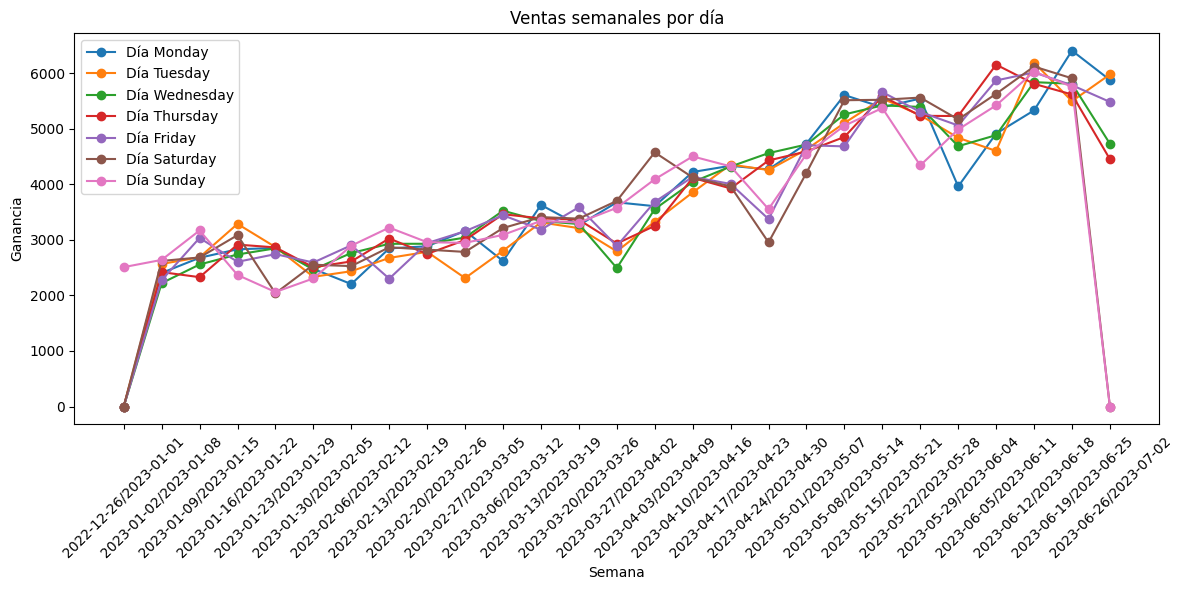

In [45]:
plt.figure(figsize=(12, 6))

for dia in ventas_dia['dia_semana'].unique():
    data_dia = ventas_dia[ventas_dia['dia_semana'] == dia]
    
    plt.plot(data_dia['semana'].astype(str), 
             data_dia['total'], 
             marker='o', 
             label=f'Día {dia}')

plt.xticks(rotation=45)
plt.xlabel("Semana")
plt.ylabel("Ganancia")
plt.title("Ventas semanales por día")
plt.legend()

plt.tight_layout()
plt.show()

In [38]:
heatmap_data = df.pivot_table(
    values='total',
    index='dia_semana',
    columns='num_hours',
    aggfunc='sum'
)

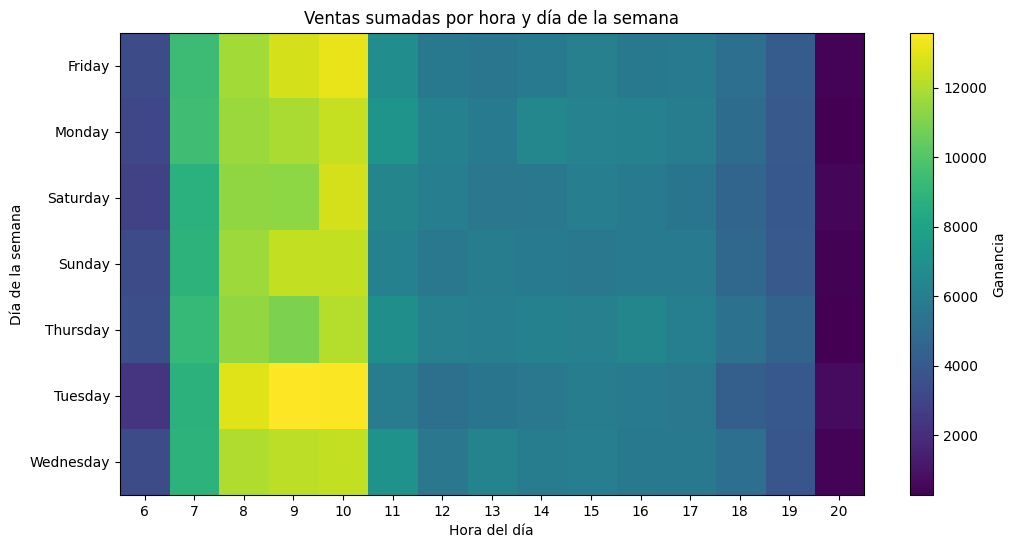

In [39]:
plt.figure(figsize=(12, 6))

plt.imshow(heatmap_data, aspect='auto')

plt.colorbar(label='Ganancia')

# Etiquetas
plt.xticks(ticks=np.arange(len(heatmap_data.columns)), labels=heatmap_data.columns)
plt.yticks(ticks=np.arange(len(heatmap_data.index)), labels=heatmap_data.index)

plt.xlabel("Hora del día")
plt.ylabel("Día de la semana")
plt.title("Ventas sumadas por hora y día de la semana")

plt.show()

In [ ]:
heatmap_data = df.pivot_table(
    values='total',
    index='dia_semana',
    columns='num_hours',
    aggfunc='count'  # mean para promedio, count para cantidad de ventas
)

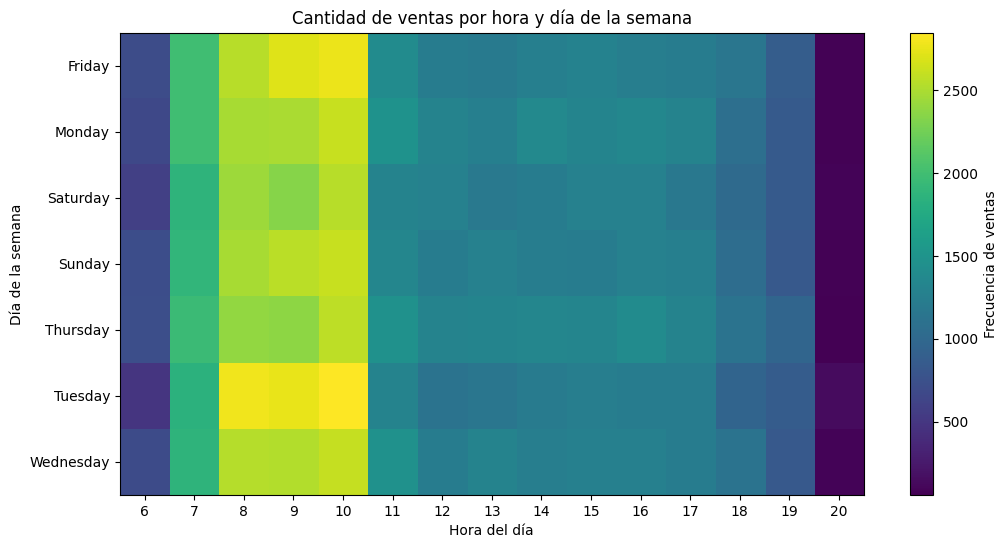

In [35]:
plt.figure(figsize=(12, 6))

plt.imshow(heatmap_data, aspect='auto')

plt.colorbar(label='Frecuencia de ventas')

# Etiquetas
plt.xticks(ticks=np.arange(len(heatmap_data.columns)), labels=heatmap_data.columns)
plt.yticks(ticks=np.arange(len(heatmap_data.index)), labels=heatmap_data.index)

plt.xlabel("Hora del día")
plt.ylabel("Día de la semana")
plt.title("Cantidad de ventas por hora y día de la semana")

plt.show()

In [46]:
data = df.copy()

def time_of_day(x):
  if x < 12:
    return 'Morning'
  elif x < 17:
    return 'Afternoon'
  else:
    return 'Evening'

def clean_info(x):
  sizes = [' Rg', ' Lg', 'Sm']
  return x.replace(sizes[0], '').replace(sizes[1], '').replace(sizes[2], '')

data['total'] = data['transaction_qty'] * data['unit_price']
data['weekday'] = data['transaction_date'].dt.day_name()
data['month'] = data['transaction_date'].dt.month_name()
data['time_of_day'] = data['transaction_time'].apply(lambda x: time_of_day(x.hour))
data['nday'] = data['transaction_date'].dt.day

data = data.drop(['transaction_id','store_id', 'product_id'], axis=1)
data['product'] = data['product_detail'].apply(lambda x: clean_info(x))
data

,transaction_date,transaction_time,transaction_qty,store_location,unit_price,product_category,product_type,product_detail,total,semana,dia_semana,num_hours,weekday,month,time_of_day,nday,product
0,2023-01-01,07:06:11,2,Lower Manhattan,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.00,2022-12-26/2023-01-01,Sunday,7,Sunday,January,Morning,1,Ethiopia
1,2023-01-01,07:08:56,2,Lower Manhattan,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.20,2022-12-26/2023-01-01,Sunday,7,Sunday,January,Morning,1,Spicy Eye Opener Chai
2,2023-01-01,07:14:04,2,Lower Manhattan,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.00,2022-12-26/2023-01-01,Sunday,7,Sunday,January,Morning,1,Dark chocolate
3,2023-01-01,07:20:24,1,Lower Manhattan,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.00,2022-12-26/2023-01-01,Sunday,7,Sunday,January,Morning,1,Our Old Time Diner Blend
4,2023-01-01,07:22:41,2,Lower Manhattan,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.20,2022-12-26/2023-01-01,Sunday,7,Sunday,January,Morning,1,Spicy Eye Opener Chai
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149111,2023-06-30,20:18:41,2,Hell's Kitchen,2.50,Tea,Brewed herbal tea,Peppermint Rg,5.00,2023-06-26/2023-07-02,Friday,20,Friday,June,Evening,30,Peppermint
149112,2023-06-30,20:25:10,2,Hell's Kitchen,3.00,Tea,Brewed Black tea,English Breakfast Lg,6.00,2023-06-26/2023-07-02,Friday,20,Friday,June,Evening,30,English Breakfast
149113,2023-06-30,20:31:34,1,Hell's Kitchen,3.00,Tea,Brewed herbal tea,Peppermint Lg,3.00,2023-06-26/2023-07-02,Friday,20,Friday,June,Evening,30,Peppermint
149114,2023-06-30,20:57:19,1,Hell's Kitchen,3.75,Coffee,Barista Espresso,Cappuccino,3.75,2023-06-26/2023-07-02,Friday,20,Friday,June,Evening,30,Cappuccino


In [47]:
data['product_detail'].apply(lambda x: clean_info(x))

0                          Ethiopia
1             Spicy Eye Opener Chai
2                    Dark chocolate
3         Our Old Time Diner Blend 
4             Spicy Eye Opener Chai
                    ...            
149111                   Peppermint
149112            English Breakfast
149113                   Peppermint
149114                   Cappuccino
149115               Hazelnut syrup
Name: product_detail, Length: 149116, dtype: object

In [48]:
data['transaction_time'].iloc[0]

datetime.time(7, 6, 11)

In [49]:
data.groupby('store_location').count()

,transaction_date,transaction_time,transaction_qty,unit_price,product_category,product_type,product_detail,total,semana,dia_semana,num_hours,weekday,month,time_of_day,nday,product
store_location,,,,,,,,,,,,,,,,
Astoria,50599,50599,50599,50599,50599,50599,50599,50599,50599,50599,50599,50599,50599,50599,50599,50599
Hell's Kitchen,50735,50735,50735,50735,50735,50735,50735,50735,50735,50735,50735,50735,50735,50735,50735,50735
Lower Manhattan,47782,47782,47782,47782,47782,47782,47782,47782,47782,47782,47782,47782,47782,47782,47782,47782


In [50]:
data.groupby('product_category').count()

,transaction_date,transaction_time,transaction_qty,store_location,unit_price,product_type,product_detail,total,semana,dia_semana,num_hours,weekday,month,time_of_day,nday,product
product_category,,,,,,,,,,,,,,,,
Bakery,22796,22796,22796,22796,22796,22796,22796,22796,22796,22796,22796,22796,22796,22796,22796,22796
Branded,747,747,747,747,747,747,747,747,747,747,747,747,747,747,747,747
Coffee,58416,58416,58416,58416,58416,58416,58416,58416,58416,58416,58416,58416,58416,58416,58416,58416
Coffee beans,1753,1753,1753,1753,1753,1753,1753,1753,1753,1753,1753,1753,1753,1753,1753,1753
Drinking Chocolate,11468,11468,11468,11468,11468,11468,11468,11468,11468,11468,11468,11468,11468,11468,11468,11468
Flavours,6790,6790,6790,6790,6790,6790,6790,6790,6790,6790,6790,6790,6790,6790,6790,6790
Loose Tea,1210,1210,1210,1210,1210,1210,1210,1210,1210,1210,1210,1210,1210,1210,1210,1210
Packaged Chocolate,487,487,487,487,487,487,487,487,487,487,487,487,487,487,487,487
Tea,45449,45449,45449,45449,45449,45449,45449,45449,45449,45449,45449,45449,45449,45449,45449,45449


In [51]:
data.groupby('product_type').count()

,transaction_date,transaction_time,transaction_qty,store_location,unit_price,product_category,product_detail,total,semana,dia_semana,num_hours,weekday,month,time_of_day,nday,product
product_type,,,,,,,,,,,,,,,,
Barista Espresso,16403,16403,16403,16403,16403,16403,16403,16403,16403,16403,16403,16403,16403,16403,16403,16403
Biscotti,5711,5711,5711,5711,5711,5711,5711,5711,5711,5711,5711,5711,5711,5711,5711,5711
Black tea,303,303,303,303,303,303,303,303,303,303,303,303,303,303,303,303
Brewed Black tea,11350,11350,11350,11350,11350,11350,11350,11350,11350,11350,11350,11350,11350,11350,11350,11350
Brewed Chai tea,17183,17183,17183,17183,17183,17183,17183,17183,17183,17183,17183,17183,17183,17183,17183,17183
Brewed Green tea,5671,5671,5671,5671,5671,5671,5671,5671,5671,5671,5671,5671,5671,5671,5671,5671
Brewed herbal tea,11245,11245,11245,11245,11245,11245,11245,11245,11245,11245,11245,11245,11245,11245,11245,11245
Chai tea,443,443,443,443,443,443,443,443,443,443,443,443,443,443,443,443
Clothing,221,221,221,221,221,221,221,221,221,221,221,221,221,221,221,221


In [52]:
data.groupby('product_detail').count()

,transaction_date,transaction_time,transaction_qty,store_location,unit_price,product_category,product_type,total,semana,dia_semana,num_hours,weekday,month,time_of_day,nday,product
product_detail,,,,,,,,,,,,,,,,
Almond Croissant,1903,1903,1903,1903,1903,1903,1903,1903,1903,1903,1903,1903,1903,1903,1903,1903
Brazilian - Organic,209,209,209,209,209,209,209,209,209,209,209,209,209,209,209,209
Brazilian Lg,2771,2771,2771,2771,2771,2771,2771,2771,2771,2771,2771,2771,2771,2771,2771,2771
Brazilian Rg,2904,2904,2904,2904,2904,2904,2904,2904,2904,2904,2904,2904,2904,2904,2904,2904
Brazilian Sm,2814,2814,2814,2814,2814,2814,2814,2814,2814,2814,2814,2814,2814,2814,2814,2814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Sustainably Grown Organic Lg,2961,2961,2961,2961,2961,2961,2961,2961,2961,2961,2961,2961,2961,2961,2961,2961
Sustainably Grown Organic Rg,2842,2842,2842,2842,2842,2842,2842,2842,2842,2842,2842,2842,2842,2842,2842,2842
Traditional Blend Chai,153,153,153,153,153,153,153,153,153,153,153,153,153,153,153,153


In [53]:
data.columns

Index(['transaction_date', 'transaction_time', 'transaction_qty',
       'store_location', 'unit_price', 'product_category', 'product_type',
       'product_detail', 'total', 'semana', 'dia_semana', 'num_hours',
       'weekday', 'month', 'time_of_day', 'nday', 'product'],
      dtype='object')

In [76]:
import pandas as pd

# Asegurar formato de fecha
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Crear variables de tiempo
df['dia_semana'] = df['transaction_date'].dt.dayofweek
df['mes'] = df['transaction_date'].dt.month
df['hora'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour
df['nday'] = df['transaction_date'].dt.day
df['quincena'] = df['nday'].apply(lambda x: 1 if x <= 15 else 2)

X = df[['dia_semana', 'hora', 'quincena']]
y = df['total']

train = df[df['transaction_date'].dt.month <= 5]
test = df[df['transaction_date'].dt.month == 6]

X_train = train[['dia_semana', 'hora']]
y_train = train['total']

X_test = test[['dia_semana', 'hora']]
y_test = test['total']

In [77]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [78]:
y_pred = model.predict(X_test)

In [79]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1.9665803839312832
RMSE: 23.874616062872086


In [80]:
print("Intercepto:", model.intercept_)
print("Coeficientes:", model.coef_)

Intercepto: 4.899583161454216
Coeficientes: [-0.00744222 -0.01690243]


In [60]:
# Predecir top 5 productos
data_dummies = pd.get_dummies(data, columns=['product_category', 'product_type', 'product_detail', 'weekday', 'month', 'time_of_day'])

data_dummies.drop(['transaction_time', 'unit_price', 'store_location', 'product'], axis=1, inplace=True)
data_dummies['transaction_date'] = pd.to_datetime(data_dummies['transaction_date'])

data_daily = data_dummies.groupby('transaction_date').sum(numeric_only=True).reset_index()

data_daily['nday'] = data_daily['transaction_date'].dt.day


data_daily


,transaction_date,transaction_qty,total,num_hours,nday,product_category_Bakery,product_category_Branded,product_category_Coffee,product_category_Coffee beans,product_category_Drinking Chocolate,...,weekday_Wednesday,month_April,month_February,month_January,month_June,month_March,month_May,time_of_day_Afternoon,time_of_day_Evening,time_of_day_Morning
0,2023-01-01,802,2508.20,7479,1,68,0,241,0,50,...,0,0,0,550,0,0,0,256,138,156
1,2023-01-02,790,2403.35,7746,2,87,0,252,0,38,...,0,0,0,566,0,0,0,281,131,154
2,2023-01-03,823,2565.00,8033,3,81,0,239,0,54,...,0,0,0,582,0,0,0,287,134,161
3,2023-01-04,726,2220.10,6890,4,61,0,222,0,43,...,497,0,0,497,0,0,0,241,136,120
4,2023-01-05,778,2418.85,7379,5,73,0,234,0,48,...,0,0,0,547,0,0,0,278,113,156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,2023-06-26,1837,5875.90,13728,26,174,5,503,10,87,...,0,0,0,0,1195,0,0,336,183,676
177,2023-06-27,1962,5975.65,15054,27,167,5,516,6,105,...,0,0,0,0,1277,0,0,344,199,734
178,2023-06-28,1531,4728.90,13760,28,147,0,492,0,88,...,1070,0,0,0,1070,0,0,446,205,419
179,2023-06-29,1429,4450.75,13206,29,170,0,424,0,82,...,0,0,0,0,1009,0,0,436,208,365


In [ ]:
import matplotlib.pyplot as plt

In [54]:
# Crear el histograma
plt.hist(data_daily['total'], bins=30, edgecolor='black', alpha=0.7)

plt.title('Frecuencia de Ventas Diarias')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')

# Mostrar el gráfico
plt.show()

NameError: name 'data_daily' is not defined

In [55]:

data_daily = data_daily.sort_values('transaction_date', ascending=False)

plt.scatter(data_daily['transaction_date'], data_daily['total'])
plt.xlabel('Fecha')
plt.ylabel('Total de ventas')
plt.title('Ventas diarias')
plt.show()

NameError: name 'data_daily' is not defined

In [ ]:
data_daily.sum().reset_index()
data_train = data_daily[data_dummies['month_June'] == 0]
data_test = data_daily[data_dummies['month_June'] == 1]

X = data_train.drop(['total','transaction_time','store_location','nday','product_detail'], axis=1)
ventaTotal = data_train['total']
X_test = data_test.drop(['total','transaction_date','transaction_time','store_location','nday'], axis=1)
ventaTotal_test = data_test['total']

In [ ]:
from sklearn.linear_model import LinearRegression
modelo_venta = LinearRegression()
modelo_venta.fit(X, ventaTotal)

In [ ]:
ventaTotal_pred = modelo_venta.predict(X_test)

In [ ]:
ventaTotal_pred
data_test['nday'].values

In [ ]:
import matplotlib.pyplot as plt
plt.plot(data_test['nday'].values, ventaTotal_pred, marker = "o") #Dibuja una línea uniendo los puntos (x,y)
plt.plot(data_test['nday'].values, ventaTotal_test, marker = "x")

plt.show()